In [171]:
%matplotlib inline
import re, sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [172]:
# Paths and output configuration
input_path = Path('Heurystyczne Genetic vs Personal 2.txt')
outdir = Path('results')
plots_dir = outdir / 'plots'
outdir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
print('Input path:', input_path)
print('Output dir:', outdir)


Input path: Heurystyczne Genetic vs Personal 2.txt
Output dir: results


In [173]:
def parse_results(text: str):
    sections = [s.strip() for s in text.split('--------------------------------------------------')]
    summaries = []
    types_list = []
    for sec in sections:
        if not sec:
            continue
        lines = [l.strip() for l in sec.splitlines() if l.strip()]
        header = lines[0]
        m = re.match(r'Running simulation:\s*(.+)\s+vs\s+(.+)', header)
        if not m:
            continue
        agent1_name = m.group(1).strip()
        agent2_name = m.group(2).strip()
        text_block = '\n'.join(lines[1:])

        def find_first(regex, default=None):
            mm = re.search(regex, text_block)
            return mm.group(1) if mm else default

        total_games = int(find_first(r'Total games:\s*(\d+)', '0'))

        a1_max = find_first(r'Agent1 max points:\s*(\d+),\s*min points:\s*(\d+)', None)
        if a1_max:
            a1_max_val = int(re.search(r'Agent1 max points:\s*(\d+)', text_block).group(1))
            a1_min_val = int(re.search(r'Agent1 max points:\s*(\d+),\s*min points:\s*(\d+)', text_block).group(2))
        else:
            a1_max_val = a1_min_val = None

        a2_max = find_first(r'Agent2 max points:\s*(\d+),\s*min points:\s*(\d+)', None)
        if a2_max:
            a2_max_val = int(re.search(r'Agent2 max points:\s*(\d+)', text_block).group(1))
            a2_min_val = int(re.search(r'Agent2 max points:\s*(\d+),\s*min points:\s*(\d+)', text_block).group(2))
        else:
            a2_max_val = a2_min_val = None

        def parse_win_line(prefix):
            mm = re.search(rf'{prefix}\s*wins:\s*(\d+),\s*avg points:\s*([\d,]+)', text_block)
            if mm:
                wins = int(mm.group(1))
                avg = float(mm.group(2).replace(',', '.'))
                return wins, avg
            return None, None

        a1_wins, a1_avg = parse_win_line('Agent1')
        a2_wins, a2_avg = parse_win_line('Agent2')

        # Parse victory types
        types = {}
        if 'Victory types count:' in text_block:
            parts = text_block.split('Victory types count:')[-1].strip()
            for line in parts.splitlines():
                if ':' not in line:
                    continue
                key, val = [p.strip() for p in line.split(':', 1)]
                try:
                    cnt = int(val)
                except ValueError:
                    try:
                        cnt = int(val.replace(',', ''))
                    except Exception:
                        continue
                # key like 'Gracz 2,Punktowe' or 'Remis,Brak'
                who, typ = [k.strip() for k in key.split(',', 1)] if ',' in key else (key, '')
                if who.lower().startswith('gracz'):
                    who_idx = 1 if '1' in who else 2
                    who_key = f'Agent{who_idx}'
                else:
                    who_key = 'Draw'
                types.setdefault((who_key, typ), 0)
                types[(who_key, typ)] += cnt

        # build summary
        summary = {
            'matchup': f"{agent1_name} vs {agent2_name}",
            'agent1_name': agent1_name,
            'agent2_name': agent2_name,
            'total_games': total_games,
            'agent1_wins': a1_wins or 0,
            'agent2_wins': a2_wins or 0,
            'agent1_avg': a1_avg,
            'agent2_avg': a2_avg,
            'agent1_max': a1_max_val,
            'agent1_min': a1_min_val,
            'agent2_max': a2_max_val,
            'agent2_min': a2_min_val,
        }
        summaries.append(summary)

        for ((who_key, typ), cnt) in types.items():
            types_list.append({
                'matchup': summary['matchup'],
                'who': who_key,
                'type': typ if typ else 'Brak',
                'count': cnt,
            })

    return pd.DataFrame(summaries), pd.DataFrame(types_list)


In [174]:
def plot_wins_grouped(summary_df: pd.DataFrame, plots_dir: Path):
    """Grouped bar: number of wins per agent for each matchup (pastel palette)"""
    wins_long = summary_df.melt(id_vars=['matchup'], value_vars=['agent1_wins', 'agent2_wins'], var_name='agent', value_name='wins')
    wins_long['agent'] = wins_long['agent'].map({'agent1_wins': 'Agent1', 'agent2_wins': 'Agent2'})

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=wins_long, x='matchup', y='wins', hue='agent')
    ax.set_xlabel('pojedynki')
    ax.set_ylabel('wygrane')
    ax.tick_params(axis='x', labelrotation=0)

    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h) and h != 0:
            ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(plots_dir / 'wins_grouped.png')
    plt.close()

In [175]:
def _type_colors(types_order):
    fixed_colors = {
        'Punktowe': '#5975A4',
        'Naukowe': '#55A868',
        'Militarne': '#C44E52',
        'Brak': '#CC8963'
    }
    palette_fallback = sns.color_palette('pastel', n_colors=max(3, len(types_order)))
    return [fixed_colors.get(t, palette_fallback[i % len(palette_fallback)]) for i, t in enumerate(types_order)]


def _label_color(fill_color):
    rgb = tuple(int(fill_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    luminance = (0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]) / 255
    return 'black' if luminance > 0.72 else 'white'

In [176]:
def _annotate_stacked_bars(ax, min_inside_height=60, percentages=False):
    """
    Dodaje czytelne etykiety (wartość + % całości słupka)
    z ciemnym obrysem wewnątrz segmentów.
    """
    import numpy as np
    
    # Krok 1: Wyliczamy sumaryczną wysokość dla każdej pozycji X (każdego słupka)
    # Pozwoli nam to odnieść wysokość segmentu do całości słupka.
    totals = {}
    for container in ax.containers:
        for rect in container:
            x_pos = rect.get_x() + rect.get_width() / 2
            # Zaokrąglamy klucz X, żeby uniknąć problemów z precyzją float
            x_key = round(x_pos, 3)
            totals[x_key] = totals.get(x_key, 0) + rect.get_height()

    # Krok 2: Nakładamy napisy
    for container in ax.containers:
        for rect in container:
            h = rect.get_height()
            if h < min_inside_height:
                continue
                
            x = rect.get_x() + rect.get_width() / 2
            y = rect.get_y() + h / 2
            x_key = round(x, 3)
            
            if percentages:
                total = totals.get(x_key, 1)
                percentage = (h / total) * 100 if total > 0 else 0
            
            # Format etykiety: "Wartość (Procent%)"
            # Jeśli podział jest bardzo ciasny, można zmienić na f"{int(h)}\n({percentage:.1f}%)"
                label_text = f"{int(h)} ({percentage:.1f}%)"
            else:
                label_text = f"{int(h)}"
            
            txt = ax.text(
                x, y, label_text, 
                ha='center', va='center', 
                fontsize=9, fontweight='bold',  # Delikatnie zmniejszony font (9), by zmieścić procenty
                color='white', clip_on=True
            )

In [177]:
def plot_types_stacked(types_df: pd.DataFrame, plots_dir: Path):
    """Stacked bar: distribution of victory types per matchup (odwrócona kolejność osi X)."""
    if types_df.empty:
        return

    pivot = types_df.pivot_table(index='matchup', columns='type', values='count', aggfunc='sum', fill_value=0)
    
    # Odwrócona kolejność pojedynków
    reversed_matchups = sorted(pivot.index, reverse=True)
    desired_order = ['Brak', 'Militarne', 'Naukowe', 'Punktowe']
    types_order = [t for t in desired_order if t in pivot.columns] + [t for t in pivot.columns if t not in desired_order]
    
    pivot = pivot.reindex(index=reversed_matchups, columns=types_order)
    colors = _type_colors(types_order)

    fig, ax = plt.subplots(figsize=(11, 6))  # Dopasowany rozmiar do reszty wykresów
    sns.set_theme(style="whitegrid")
    
    pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.65, edgecolor='white', linewidth=0.5)

    ax.set_xlabel('pojedynki', fontsize=11, labelpad=10)
    ax.set_ylabel('liczba', fontsize=11, labelpad=10)
    ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    
    ax.legend(title='Typ', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9, title_fontsize=9)

    _annotate_stacked_bars(ax, min_inside_height=60, percentages=True)

    plt.tight_layout()
    plt.savefig(plots_dir / 'types_stacked.png', dpi=150)
    plt.close()

In [178]:
def plot_types_stacked_by_agent(types_df: pd.DataFrame, plots_dir: Path):
    """Tworzy pogrupowane słupki (Agent1 obok Agent2) w odwróconej kolejności pojedynków."""
    if types_df.empty:
        return

    pivot = types_df.pivot_table(index=['matchup', 'who'], columns='type', values='count', aggfunc='sum', fill_value=0)
    desired_order = ['Brak', 'Militarne', 'Naukowe', 'Punktowe']
    types_order = [t for t in desired_order if t in pivot.columns] + [t for t in pivot.columns if t not in desired_order]
    pivot = pivot[types_order].reset_index()

    # Odwrócona kolejność pojedynków
    matchups = sorted(pivot['matchup'].unique(), reverse=True)
    
    fig, ax = plt.subplots(figsize=(11, 6))  # Zrównany rozmiar okna wykresu
    sns.set_theme(style="whitegrid")

    x = np.arange(len(matchups))
    width = 0.4  # Dopasowana szerokość podwójnych słupków
    colors = _type_colors(types_order)

    for i, agent in enumerate(['Agent1', 'Agent2']):
        sub_df = pivot[pivot['who'] == agent].set_index('matchup')
        numeric_df = sub_df.reindex(matchups, fill_value=0)[types_order]
        
        pos = x - width/2 if i == 0 else x + width/2
        bottoms = np.zeros(len(matchups))
        
        for t_idx, typ in enumerate(types_order):
            vals = numeric_df[typ].values
            label = typ if i == 0 else "_" + typ 
            
            ax.bar(
                pos, vals, width, bottom=bottoms, 
                color=colors[t_idx], label=label,
                edgecolor='white', linewidth=0.5
            )
            bottoms += vals

    # Ujednolicenie stylizacji z pozostałymi wykresami
    ax.set_ylabel('liczba', fontsize=11, labelpad=10)
    ax.set_xlabel('pojedynki', fontsize=11, labelpad=20)  # Większy pad, bo na dole są podpisy Agentów
    
    ax.set_xticks(x)
    ax.set_xticklabels(matchups, fontsize=11)
    ax.tick_params(axis='y', labelsize=9)

    # Małe etykiety agentów pod słupkami (przesunięte delikatnie w dół)
    # y_offset wyliczany automatycznie względem skali osi Y, żeby nie nakładał się na siatkę
    y_min, y_max = ax.get_ylim()
    y_offset = -(y_max * 0.035) 
    
    ax.legend(title='Typ', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9, title_fontsize=9)

    _annotate_stacked_bars(ax, min_inside_height=60)

    plt.tight_layout()
    plt.savefig(plots_dir / 'types_stacked_by_agent.png', bbox_inches='tight', dpi=150)
    plt.close()

In [179]:
def make_plots(summary_df: pd.DataFrame, types_df: pd.DataFrame, outdir: Path):
    outdir.mkdir(parents=True, exist_ok=True)
    plots_dir = outdir / 'plots'
    plots_dir.mkdir(exist_ok=True)

    plot_wins_grouped(summary_df, plots_dir)
    plot_types_stacked(types_df, plots_dir)
    plot_types_stacked_by_agent(types_df, plots_dir)

Saved results to results


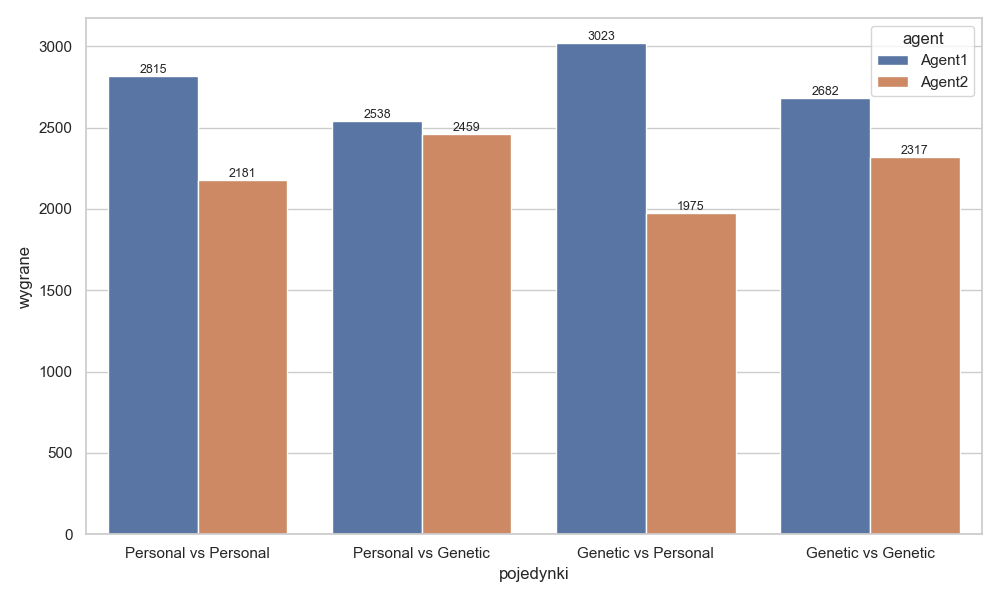

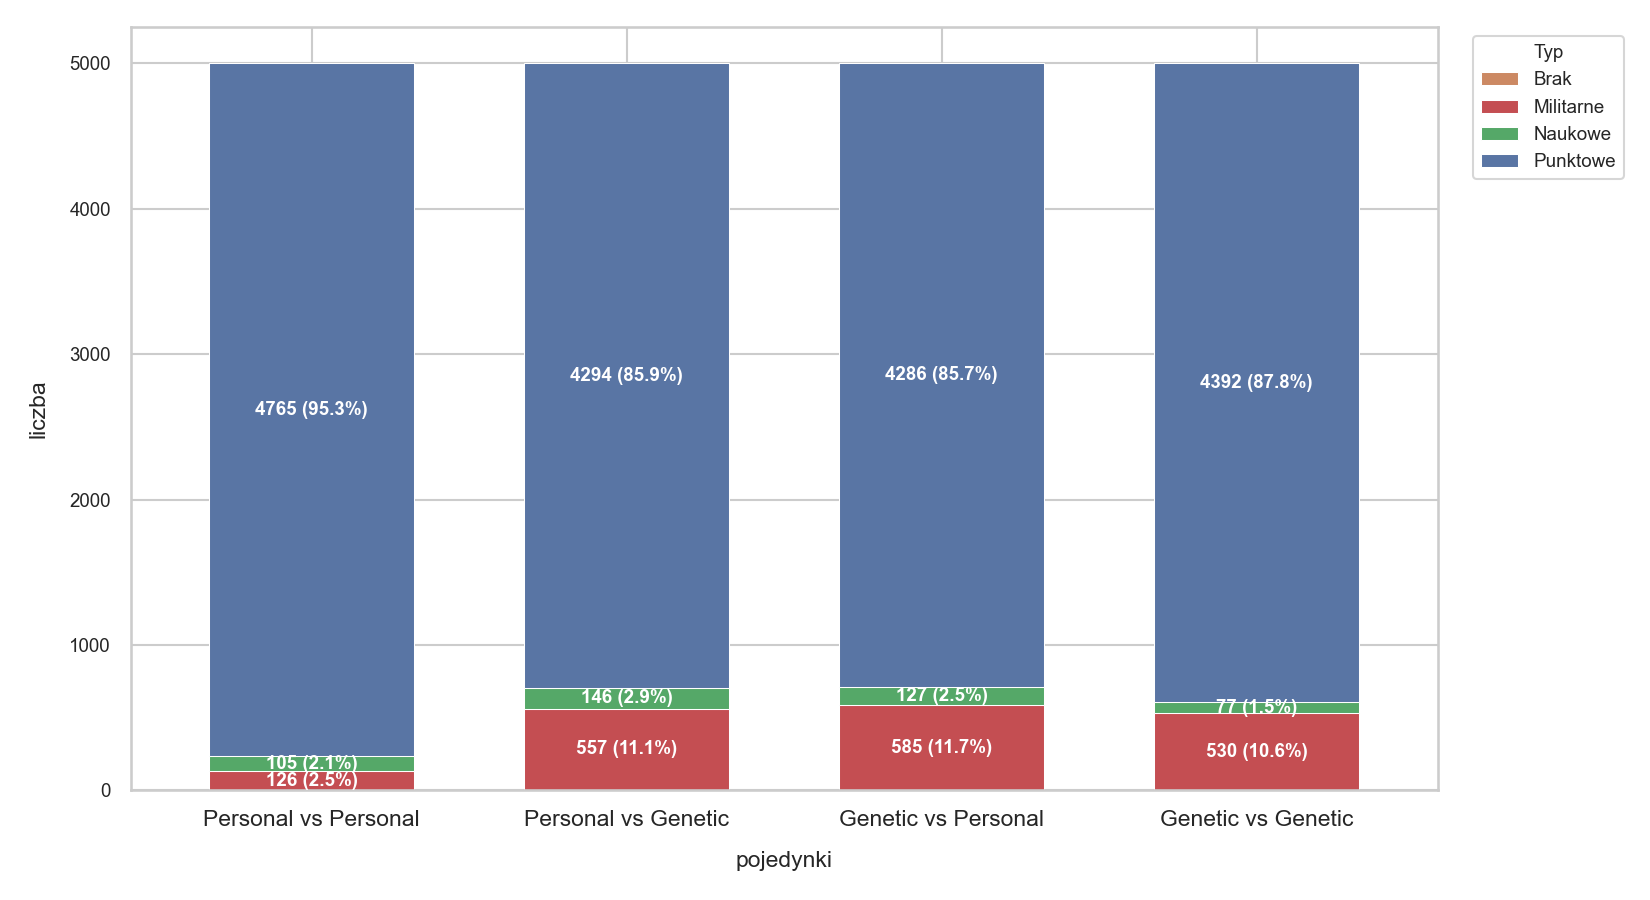

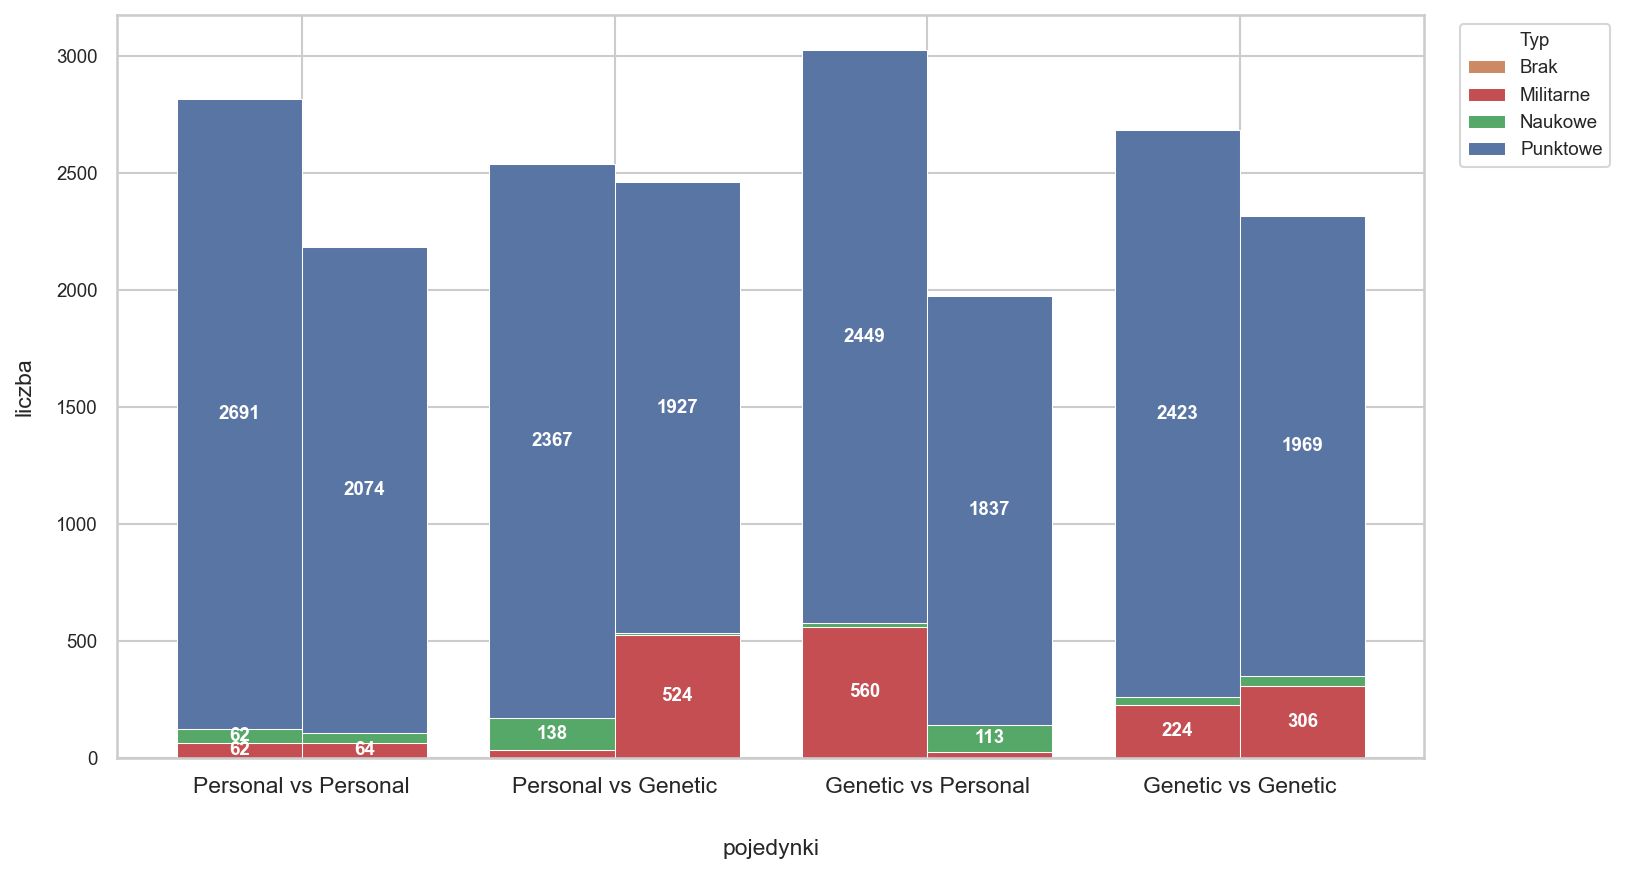

In [180]:
# Full pipeline: read -> parse -> save CSVs -> plots
from IPython.display import Image, display

if input_path.exists():
    text = input_path.read_text(encoding='utf-8')
else:
    print('Input not found, using sample text from previous cell')
    text = sample_text

summary_df, types_df = parse_results(text)
summary_df.to_csv(outdir / 'results_summary.csv', index=False)
types_df.to_csv(outdir / 'results_types.csv', index=False)
make_plots(summary_df, types_df, outdir)

print('Saved results to', outdir)
# display generated plots
for fname in ['wins_grouped.png','types_stacked.png','types_stacked_by_agent.png']:
    p = plots_dir / fname
    if p.exists():
        display(Image(str(p)))
    else:
        print('Missing:', p)
